# 03 — Freezing the folds

Workflow step 3, closing it out. Display only; all logic lives in `src/s6e7/`
(CLAUDE.md rule 5).

Notebook 02 established that train and test are **not** one distribution:
adversarial AUC **0.6518** against a 0.5002 shuffled control, with every one of the
13 marginals at chance. That reopened the fold design.

This notebook does three things:

1. **Locates** the shift — which channel carries it.
2. **Prices** it — how much it could cost, in the units of the CV resolution.
3. **Freezes** the partition and checks the freeze did what it promised.

The conclusion is a negative result, which is the usual kind: the shift is real, it
sits in a direction that carries no target signal, and the design does not change.
Written down so it is a decision rather than an omission.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import polars as pl

from s6e7 import adversarial, eda, folds, io, plots

pl.Config.set_tbl_rows(25)
pl.Config.set_tbl_cols(20)
pl.Config.set_tbl_width_chars(200)

polars.config.Config

In [2]:
train = io.load_train()
test = io.load_test()

train.shape, test.shape

((690088, 15), (295753, 14))

---
## 1. Where does the shift live?

An AUC is one number, and one number cannot tell you what to do. To act on it you have
to decompose it, and the way to decompose a shift is to **take a channel away and
re-run**.

Complete-case rows carry no nulls at all, so a classifier restricted to them *physically
cannot* use the missingness pattern. Whatever AUC survives is the shift in the observed
**values**; the drop is the part that was missingness.

The control row matters more here than on full data. Filtering to complete cases changes
both sample sizes and selects on the very thing under suspicion — the restricted harness
has to be shown reading chance as chance before its 0.53 means anything.

*Roughly two minutes on full data.*

In [3]:
adversarial.missingness_ablation(train, test)

run,n_train,n_test,auc,auc_sd
str,i64,i64,f64,f64
"""all rows""",690088,295753,0.6518,0.0012
"""complete cases""",349623,165084,0.5304,0.0018
"""complete cases, shuffled contr…",349623,165084,0.4999,null


**0.6518 → 0.5304**, against a 0.4999 control. Strip the null pattern and most of the
shift goes with it — the restricted figure is below `adversarial.SHIFT_THRESHOLD` (0.55).

A residual remains, and it is not zero: the values do differ slightly. `solo_auc` on the
restricted frames says which columns, and the answer is a mild drift in two low-cardinality
categoricals (`smoking_alcohol` 0.5186, `gender` 0.5133). A marginal drift hits every model
equally — it moves the level, not the ranking. Uncomment to re-run; it takes a few minutes.

In [4]:
# adversarial.solo_auc(
#     adversarial.complete_cases(train), adversarial.complete_cases(test)
# ).head(4)

---
## 2. Does the shifted quantity predict the target?

This is the question that actually decides the fold design. Covariate shift only costs
you where `p(y|x)` has structure. If the per-row null count carries no target signal,
then what shifted predicts nothing and the folds do not have to answer for it.

The trap: reading the unsplit rates. One informative null indicator bends them all on its
own, and the bend looks exactly like the *count* mattering. `bmi_is_null` is that
indicator here — `p(unhealthy)` drops 0.0848 → 0.0293 when `bmi` is missing (~22σ, from
notebook 01), and null-heavy rows are more likely to be missing `bmi` by simple
arithmetic.

So split on it. Flat rates **within** each half mean the count adds nothing beyond the
indicator.

In [5]:
eda.null_count_vs_target(train, io.FEATURE_COLS, io.TARGET, split_on="bmi").select(
    "split", "n_nulls", "n_rows", "pct_unhealthy", "se_unhealthy", "pct_fit", "se_fit"
)

split,n_nulls,n_rows,pct_unhealthy,se_unhealthy,pct_fit,se_fit
str,i64,i64,f64,f64,f64,f64
"""bmi present""",0,349623,8.469,0.047,5.727,0.039
"""bmi present""",1,241037,8.51,0.057,5.712,0.047
"""bmi present""",2,72224,8.324,0.103,5.74,0.087
"""bmi present""",3,12000,8.892,0.26,5.392,0.206
"""bmi present""",4,1235,8.826,0.807,5.911,0.671
"""bmi null""",1,7097,2.79,0.195,8.313,0.328
"""bmi null""",2,5087,2.988,0.239,8.178,0.384
"""bmi null""",3,1445,3.114,0.457,7.682,0.701
"""bmi null""",4,244,4.918,1.384,8.607,1.795


Flat in `n_nulls` inside each half — every deviation sits within 1–2 SE of the others.
The null *count* carries no signal beyond the `bmi` indicator.

And the indicator itself did not shift:

In [6]:
print(f"p(bmi null)   train {train['bmi'].null_count() / train.height:.5f}"
      f"   test {test['bmi'].null_count() / test.height:.5f}")

p(bmi null)   train 0.02014   test 0.02014


**The quantity that shifted predicts nothing; the quantity that predicts did not shift.**

That sentence is what closed the decision. No amount of staring at 0.6518 would have
produced it.

---
## 3. Pricing the options

The shift is real, so the remaining question is whether correcting for it buys more than
it costs. Price every option against the resolution already computed in notebook 01:
`SE(cv_mean) ≈ 0.001`, expected `cv_std ≈ 0.002`.

The shifted region is rows with ≥3 nulls: **2.17% of train, 4.55% of test.**

| Option | Buys | Priced |
|---|---|---|
| `StratifiedKFold(5)` on target alone | nothing new | CV optimistic by ~0.001–0.002 |
| compound key: target × null bucket | equal null composition across folds | **0.00004** |
| importance-weighted OOF scoring | corrects level *and* ranking | corrects ≤0.002, with estimated weights |
| pessimistic test-like folds | CV that undershoots LB | same ≤0.002, and folds stop being exchangeable |

**Why the compound key fails its own arithmetic.** Per-fold share of the k≥3 bucket has
`SE = √(0.0217 · 0.978 / 138,018) = 0.00039`. Even assuming a generous 0.10 difficulty gap
between null-heavy and null-light rows, that moves a fold score by `0.00039 × 0.10 =`
**0.00004** — four orders below the 0.002 fold SE, in exchange for a compound key frozen
forever.

Note what it would even do: stratifying makes the folds resemble **each other**, not test.
Variance reduction, not shift correction.

**Why the ranking is safe.** Two models tied overall but differing by δ on the k≥3 slice
have the gap between them moved by `(0.0455 − 0.0217) · δ = 0.0238 · δ`. For that to
outrun the 0.001 resolution:

    0.0238 · δ > 0.001   →   δ > 0.042

A four-point balanced-accuracy advantage confined to 2% of the rows, while otherwise tied.
The one design axis where that is not absurd is **missing-data handling** — which is
exactly what the diagnostic bucket below is carried for.

---
## 4. Freeze

`build()` writes `data/processed/folds.parquet` on the first call and **returns the
existing path untouched** on every call after. Re-running this cell does not re-split.

The assignment is deterministic anyway — same data, seed 42, same `StratifiedKFold` — so
why a file at all? Because determinism only holds while the inputs hold. A changed seed,
a changed `n_splits`, or a re-downloaded CSV in a different row order would produce a
different partition **silently**, invalidating every `cv_mean` logged before it. The file
is what survives that, and `verify()` is what tells you it happened.

In [7]:
path = folds.build()
print(f"frozen -> {path}")

folds.verify()
print("verify(): the frozen file re-derives exactly")

frozen -> D:\Kaggle\comp-playground-series-s6e7\data\processed\folds.parquet


verify(): the frozen file re-derives exactly


In [8]:
folds.load().head()

id,fold,null_bucket
u32,i8,u8
0,0,0
1,1,0
2,4,0
3,3,0
4,3,2


`null_bucket` rides along as a **diagnostic slice key, not a stratification key** — the
distinction priced in section 3. It costs one column and lets every experiment report
per-slice recall, which is what would catch the section-2 reasoning being wrong.

---
## 5. Did the freeze do what it promised?

Two readings, and they answer different questions.

**The stratified dimension must be boring.** This is a receipt, not a finding.

In [9]:
composition = folds.composition(train, test=test)

composition.select("source", "n_rows", "n_at-risk", "n_fit", "n_unhealthy")

source,n_rows,n_at-risk,n_fit,n_unhealthy
str,i64,i64,i64,i64
"""fold_0""",138018,118512,7961,11545
"""fold_1""",138018,118512,7961,11545
"""fold_2""",138018,118512,7961,11545
"""fold_3""",138017,118512,7960,11545
"""fold_4""",138017,118513,7960,11544
"""train""",690088,592561,39803,57724
"""test""",295753,null,null,null


`fit` lands 7961 / 7961 / 7961 / 7960 / 7960 — exact to one row, which is the most
stratification can do with 39,803 rows and 5 folds. If this were ever *not* boring, the
splitter would be broken.

That 7,961 is the number the whole harness's resolution rests on: `√(0.21 / 7961) = 0.0051`
on the `fit` recall per fold.

**The unstratified dimension is where the information is.**

In [10]:
composition.select("source", "pct_k0", "pct_k1", "pct_k2", "pct_k3plus")

source,pct_k0,pct_k1,pct_k2,pct_k3plus
str,f64,f64,f64,f64
"""fold_0""",50.533,35.983,11.262,2.221
"""fold_1""",50.779,35.909,11.15,2.162
"""fold_2""",50.617,36.028,11.191,2.164
"""fold_3""",50.785,35.859,11.194,2.163
"""fold_4""",50.603,36.006,11.219,2.172
"""train""",50.664,35.957,11.203,2.177
"""test""",55.818,29.029,10.589,4.564


Two things to read off that table.

**The folds agree with each other.** `pct_k3plus` spans 2.162–2.221 around a pooled 2.177.
Predicted SE is 0.039pp, so the widest fold is 1.1 SE out — exactly the drift the binomial
says to expect. Larger would mean a bug, not variance.

**No fold agrees with test.** Test sits at **4.564%** against folds clustered at 2.17% with
a ±0.08pp band — roughly 30 SE away. That is the shift, in one line, and it is deliberate:
section 3 is the argument for not chasing it.

Which gives a falsifiable prediction to write into the ledger *before* the first submission:

> Test rows carry more nulls, so they are information-poorer.
> **LB should land ~0.001–0.002 below CV.**

A gap of 0.02 means this analysis is not the explanation and something else is wrong.
Committing to the sign and magnitude in advance is what makes the first submission
informative.

---
## 6. Using them

Join by `id`, never by row position. `fold_vector` does that with `validate="1:1"` and
`maintain_order="left"` — without the second, polars does not guarantee the output order
and you would get a correct set of labels attached to the wrong rows, which produces a
plausible number rather than an error.

In [11]:
fold = folds.fold_vector(train)

for k, (fit_idx, val_idx) in enumerate(folds.iter_folds(fold)):
    print(f"fold {k}:  fit {len(fit_idx):>7,}   val {len(val_idx):>7,}")

fold 0:  fit 552,070   val 138,018
fold 1:  fit 552,070   val 138,018
fold 2:  fit 552,070   val 138,018
fold 3:  fit 552,071   val 138,017
fold 4:  fit 552,071   val 138,017


In [12]:
shuffled = train.sample(fraction=1.0, shuffle=True, seed=1)
by_id = dict(zip(train["id"], fold, strict=True))

print("row order respected:", all(by_id[i] == f for i, f in zip(
    shuffled["id"], folds.fold_vector(shuffled), strict=True)))

row order respected: True


---
## 7. The picture

`plots.fold_distribution` draws both dimensions of section 5 in one figure. The
organising principle: **show what stratification did *not* fix.**

**Left — the stratified dimension, as a receipt.** Per-fold class counts as deviation
from the class mean *in rows*: a 0–100% axis would show five identical bars, so the
deviation is the entire content. Within ±1 row is the most stratification can do.

**Right — the unstratified dimension, where the information is.** Null-bucket shares as
deviation from pooled train; the grey band is ±2 SE (inside = binomial drift, outside =
bug), and the dashed line is test. The honest answer to "are my folds like test?" is
*no, deliberately* — that gap is the LB-below-CV prediction, drawn.

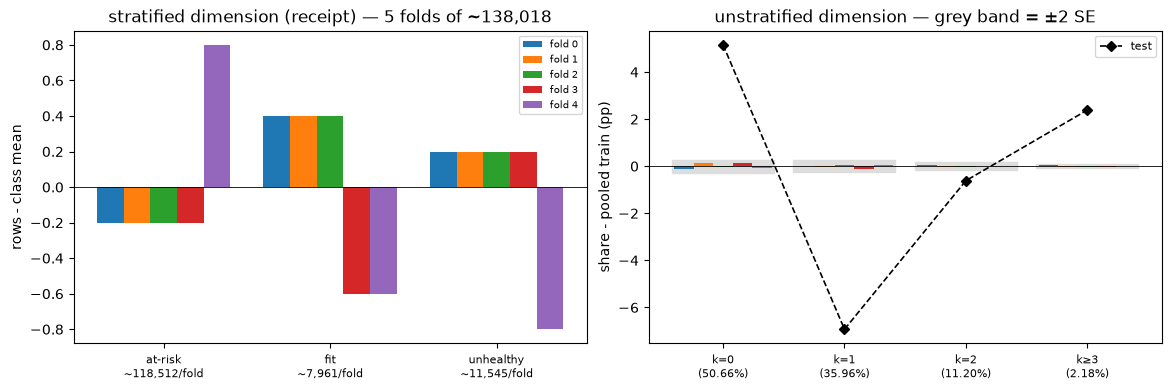

In [13]:
plots.fold_distribution(train, fold, io.TARGET, test=test)